# 6 · Comparación de resultados: métricas, tiempos y volumen

Cada par de modelos (scikit-learn y PySpark) comparte **la misma familia de modelos** (los optimizadores y
la forma de elegir los cortes difieren entre motores), **espacios de búsqueda equivalentes**, **3 pliegues
idénticos**, **las mismas variables** y **la misma partición** entrenamiento/prueba. Todos se entrenaron en
**la misma máquina**, **uno a la vez** y sin otros procesos pesados durante las mediciones de tiempo. La
comparación **estadística** (¿son reales las diferencias?) está en el capítulo 5; aquí se resumen métricas
y tiempos.

**Máquina:** Intel Core i5-13420H (8 núcleos, 12 hilos lógicos), 16 GB de RAM, Windows 11. Spark en modo local
(`local[*]`) con la configuración del capítulo 3.

In [1]:
import json
import platform
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score, roc_auc_score, roc_curve

sys.path.insert(0, str(Path.cwd().parent))
from src import lc_models as lm  # noqa: E402
from src import lc_utils as lc  # noqa: E402

warnings.filterwarnings("ignore")
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold"})
RESULTS = Path("../resultados")
sk = json.loads((RESULTS / "sk_resultados.json").read_text())
sp = json.loads((RESULTS / "sp_resultados.json").read_text())
R_SK, R_SP = sk["modelos"], {k: json.loads((RESULTS / f"sp_modelo_{k}.json").read_text()) for k in lm.CLAVES}
ENT = {"sk": "scikit-learn", "sp": "PySpark"}
print(f"Equipo de los experimentos: Spark {sp['spark_version']} · {sk['hilos']} hilos lógicos · RAM {sk['ram_gb']:.1f} GB · heap JVM {sp['heap_jvm_gb']:.1f} GB")

Equipo de los experimentos: Spark 3.5.9 · 12 hilos lógicos · RAM 16.9 GB · heap JVM 8.6 GB


## 6.1 Métricas de los seis modelos en los dos entornos

Todas sobre el **mismo conjunto de prueba**. Las métricas con umbral (exactitud, precisión, sensibilidad y F1) usan
el umbral elegido **con el entrenamiento** de cada modelo (F1 sobre puntuaciones fuera de pliegue).

In [2]:
a, b = pd.read_parquet(RESULTS / "sk_scores_test.parquet"), None
S, y = {}, a["y"].to_numpy()
for k in lm.CLAVES:
    S[("sk", k)] = a[k].to_numpy()
    p = pd.read_parquet(RESULTS / f"sp_scores_test_{k}.parquet")
    S[("sp", k)] = a[["id"]].merge(p, on="id", how="left")["score"].to_numpy()
UMB = {("sk", k): R_SK[k]["umbral_f1"] for k in lm.CLAVES} | {("sp", k): R_SP[k]["umbral_f1"] for k in lm.CLAVES}
filas = []
for (e, k), s in S.items():
    mt = lc.threshold_metrics(y, s, UMB[(e, k)])
    filas.append({"modelo": lm.NOMBRES[k], "entorno": ENT[e], "ROC AUC": roc_auc_score(y, s), "AUC-PR": average_precision_score(y, s),
                  "accuracy": mt["accuracy"], "precision": mt["precision"], "recall": mt["recall"], "f1": mt["f1"], "umbral": mt["umbral"]})
tab = pd.DataFrame(filas)
orden = [lm.NOMBRES[k] for k in lm.CLAVES]
piv = tab.pivot(index="modelo", columns="entorno", values=["ROC AUC", "AUC-PR", "accuracy", "precision", "recall", "f1"]).loc[orden]
display(piv.swaplevel(axis=1).sort_index(axis=1, level=0, sort_remaining=False))
tab.to_csv(RESULTS / "comparacion_metricas.csv", index=False)
dif = (piv["ROC AUC"]["scikit-learn"] - piv["ROC AUC"]["PySpark"]).rename("ΔAUC (scikit-learn − PySpark)")
display(dif.to_frame())

entorno             PySpark                                         scikit-learn                                        
                    ROC AUC AUC-PR accuracy precision recall     f1      ROC AUC AUC-PR accuracy precision recall     f1
modelo                                                                                                                  
Regresión logística  0.7095 0.3700   0.6699    0.3274 0.6200 0.4285       0.7095 0.3700   0.6665    0.3256 0.6259 0.4283
Árbol de decisión    0.7004 0.3564   0.6497    0.3140 0.6367 0.4205       0.7022 0.3594   0.6510    0.3142 0.6329 0.4199
Bosque aleatorio     0.7152 0.3815   0.6759    0.3324 0.6187 0.4325       0.7164 0.3821   0.6785    0.3345 0.6168 0.4337
Gradient boosting    0.7189 0.3863   0.6798    0.3361 0.6194 0.4358       0.7196 0.3875   0.6904    0.3428 0.6009 0.4366
SVM lineal           0.5985 0.2854   0.7032    0.3077 0.3891 0.3436       0.4956 0.2036   0.2020    0.1993 0.9936 0.3320
Naive Bayes          0.6883 0.3479   0.6505    0.3115 0.6200 0.4146       0.6884 0.3480   0.6473    0.3100 0.6259 0.4147

,ΔAUC (scikit-learn − PySpark)
modelo,
Regresión logística,0.0000
Árbol de decisión,0.0018
Bosque aleatorio,0.0012
Gradient boosting,0.0007
SVM lineal,-0.1029
Naive Bayes,0.0001


**¿Son reales estas diferencias?** La prueba se hace en el capítulo 5 (DeLong pareado, McNemar y
*bootstrap*, con corrección de Holm); aquí se reproducen esas tres columnas junto al ΔAUC de cada modelo.

In [3]:
est = pd.read_csv(RESULTS / "estadistica_resumen_tres_pruebas.csv")
est_a = est[est["familia"] == "A"].copy()
est_a["modelo"] = est_a["comparación"].str.split(":").str[0]
est_a = est_a.set_index("modelo").loc[orden]
resumen_dif = pd.DataFrame({
    "ΔAUC (scikit-learn − PySpark)": dif,
    "ΔAUC bootstrap [IC95]": est_a["boot ΔAUC [IC95]"],
    "p DeLong (Holm)": est_a["DeLong p Holm"],
    "p McNemar (Holm)": est_a["McNemar p Holm"],
    "relevante (|ΔAUC| ≥ 0.005)": est_a["relevante"],
})
display(resumen_dif.style.format({"ΔAUC (scikit-learn − PySpark)": "{:+.4f}", "p DeLong (Holm)": "{:.2e}", "p McNemar (Holm)": "{:.2e}"}))

,ΔAUC (scikit-learn − PySpark),ΔAUC bootstrap [IC95],p DeLong (Holm),p McNemar (Holm),relevante (|ΔAUC| ≥ 0.005)
modelo,,,,,
Regresión logística,+0.0000,"+0.0000 [-0.0000, +0.0000]",4.84e-01,2.85e-119,False
Árbol de decisión,+0.0018,"+0.0018 [+0.0007, +0.0029]",3.07e-03,5.75e-02,False
Bosque aleatorio,+0.0012,"+0.0012 [+0.0008, +0.0016]",4.05e-08,1.77e-10,False
Gradient boosting,+0.0007,"+0.0007 [+0.0002, +0.0011]",3.83e-03,2.65e-130,False
SVM lineal,-0.1029,"-0.1029 [-0.1064, -0.0995]",0.00e+00,0.00e+00,True
Naive Bayes,+0.0001,"+0.0001 [+0.0001, +0.0001]",1.27e-34,2.68e-111,False


## 6.2 Curvas ROC y precisión–recall (un gráfico por entorno, con los seis modelos)

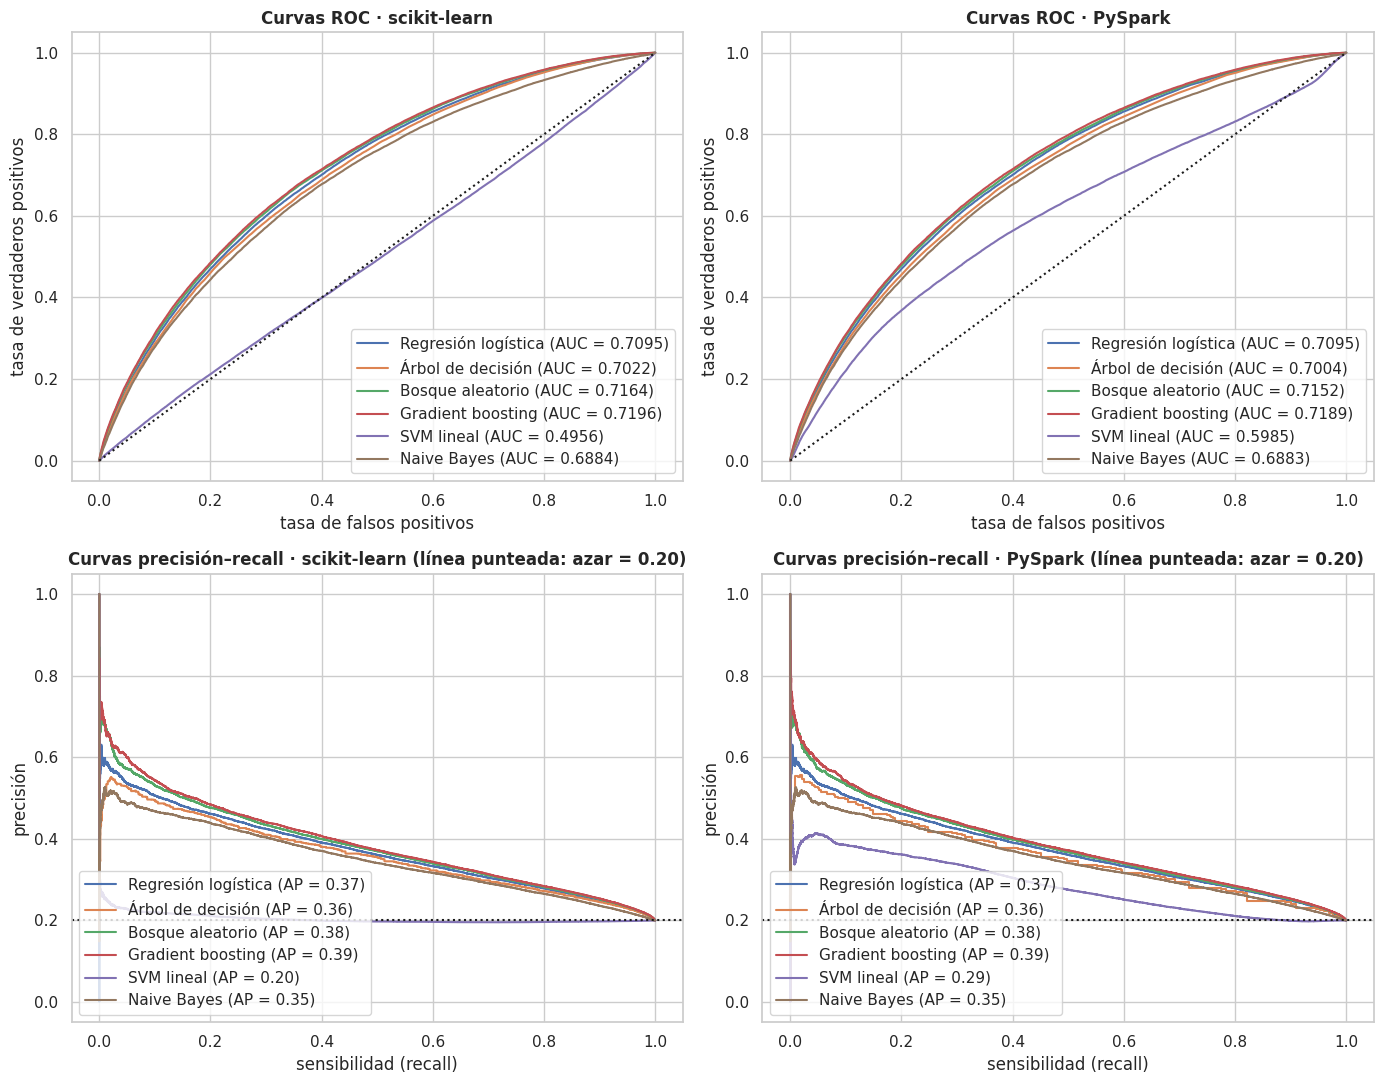

In [4]:
fig, ax = plt.subplots(2, 2, figsize=(14, 11))
for j, e in enumerate(("sk", "sp")):
    for k in lm.CLAVES:
        fpr, tpr, _ = roc_curve(y, S[(e, k)])
        ax[0, j].plot(fpr, tpr, label=f"{lm.NOMBRES[k]} (AUC = {roc_auc_score(y, S[(e, k)]):.4f})")
        PrecisionRecallDisplay.from_predictions(y, S[(e, k)], name=lm.NOMBRES[k], ax=ax[1, j])
    ax[0, j].plot([0, 1], [0, 1], "k:")
    ax[0, j].set(xlabel="tasa de falsos positivos", ylabel="tasa de verdaderos positivos")
    ax[0, j].legend(loc="lower right")
    ax[0, j].set_title(f"Curvas ROC · {ENT[e]}")
    ax[1, j].set(xlabel="sensibilidad (recall)", ylabel="precisión")
    ax[1, j].axhline(y.mean(), color="k", ls=":")
    ax[1, j].set_title(f"Curvas precisión–recall · {ENT[e]} (línea punteada: azar = {y.mean():.2f})")
plt.tight_layout()
plt.show()

## 6.3 Tiempos de cómputo por modelo y por entorno

Se comparan las etapas equivalentes. **La "carga" y el "preprocesamiento" se comparan juntos**: Spark lee de
forma perezosa y descarta las columnas que no usa, así que su tiempo de "carga" aislado no es comparable con el
de pandas (que convierte las columnas a memoria). Para scikit-learn la fila suma leer las 24 columnas
necesarias, construir variables, codificar y escalar; para Spark incluye leer, construir variables, unir con la
partición, ajustar los transformadores (incluido el escalador) y **cachear**. El arranque de la sesión de Spark
y la **transferencia** de `id`, `default` y puntuación al driver se muestran aparte.

entorno,PySpark,scikit-learn,PySpark / scikit-learn
modelo,,,
Regresión logística,"3,800.2",14.8,257.0×
Árbol de decisión,"3,867.4",59.4,65.1×
Bosque aleatorio,"21,184.1",843.2,25.1×
Gradient boosting,"36,421.5","3,268.0",11.1×
SVM lineal,"12,956.0",623.9,20.8×
Naive Bayes,"2,562.3",5.4,477.9×
TOTAL seis modelos,"4,814.6","80,791.5",16.8×


Preprocesamiento (carga + variables + codificación + escalado): scikit-learn 43 s · PySpark 323 s (arranque de la sesión de Spark aparte: 24 s)


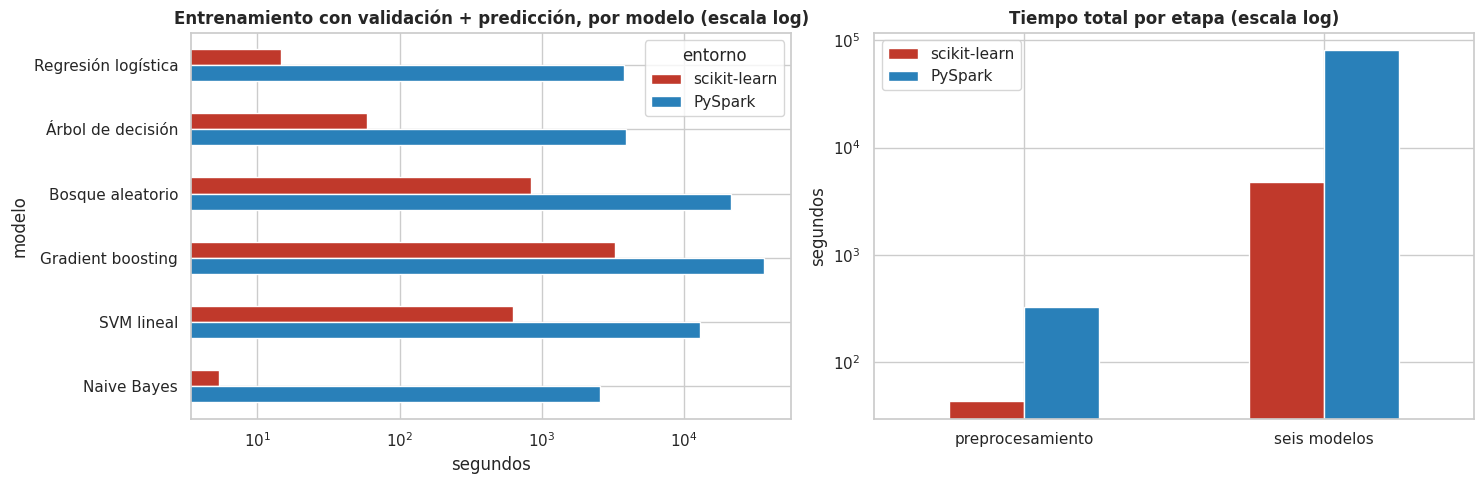

TOTAL (preprocesamiento + seis modelos): scikit-learn 81.0 min · PySpark 1,351.9 min · razón 16.7×


In [5]:
t_prep_sk = sk["tiempos_comunes_s"]["carga_csv"] + sk["tiempos_comunes_s"]["features"] + sk["tiempos_comunes_s"]["preprocesamiento"]
t_prep_sp = sp["tiempos_s"]["preprocesamiento"]
filas = []
for k in lm.CLAVES:
    for e, r in (("sk", R_SK[k]), ("sp", R_SP[k])):
        filas.append({"modelo": lm.NOMBRES[k], "entorno": ENT[e], "entrenamiento con validación (s)": r["t_entrenamiento_con_cv_s"],
                      "predicción test (s)": r["t_prediccion_s"], "umbral OOF (s)": r["t_oof_umbral_s"],
                      "transferencia al driver (s)": r.get("t_transferencia_s", np.nan)})
tiempos = pd.DataFrame(filas)
tiempos["entrenamiento + predicción (s)"] = tiempos["entrenamiento con validación (s)"] + tiempos["predicción test (s)"]
tt = tiempos.pivot(index="modelo", columns="entorno", values="entrenamiento + predicción (s)").loc[orden]
tt["PySpark / scikit-learn"] = tt["PySpark"] / tt["scikit-learn"]
tt.loc["TOTAL seis modelos"] = [tt["scikit-learn"].sum(), tt["PySpark"].sum(), tt["PySpark"].sum() / tt["scikit-learn"].sum()]
display(tt.style.format({"scikit-learn": "{:,.1f}", "PySpark": "{:,.1f}", "PySpark / scikit-learn": "{:.1f}×"}))
det = tiempos.set_index(["modelo", "entorno"])
display(det.style.format("{:,.1f}"))
print(f"Preprocesamiento (carga + variables + codificación + escalado): scikit-learn {t_prep_sk:.0f} s · PySpark {t_prep_sp:.0f} s "
      f"(arranque de la sesión de Spark aparte: {sp['tiempos_s'].get('arranque_sesion', float('nan')):.0f} s)")
tiempos.to_csv(RESULTS / "comparacion_tiempos.csv", index=False)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
piv_t = tiempos.pivot(index="modelo", columns="entorno", values="entrenamiento + predicción (s)").loc[orden]
piv_t[["scikit-learn", "PySpark"]].plot.barh(ax=ax[0], color=["#c0392b", "#2980b9"], logx=True)   # mismo color por entorno en ambos paneles
ax[0].set(title="Entrenamiento con validación + predicción, por modelo (escala log)", xlabel="segundos")
ax[0].invert_yaxis()
tot = pd.DataFrame({"scikit-learn": [t_prep_sk, piv_t["scikit-learn"].sum()], "PySpark": [t_prep_sp, piv_t["PySpark"].sum()]},
                   index=["preprocesamiento", "seis modelos"])
tot.plot.bar(ax=ax[1], color=["#c0392b", "#2980b9"], logy=True, rot=0)
ax[1].set(title="Tiempo total por etapa (escala log)", ylabel="segundos")
plt.tight_layout()
plt.show()
TOT_SK, TOT_SP = t_prep_sk + piv_t["scikit-learn"].sum(), t_prep_sp + piv_t["PySpark"].sum()
print(f"TOTAL (preprocesamiento + seis modelos): scikit-learn {TOT_SK / 60:,.1f} min · PySpark {TOT_SP / 60:,.1f} min · razón {TOT_SP / TOT_SK:.1f}×")

## 6.4 ¿Desde qué volumen de datos cambia el ganador en velocidad?

Se ajustó **un bosque fijo** (50 árboles, profundidad 10) con subconjuntos crecientes del entrenamiento en
scikit-learn y en PySpark (con las 400 particiones de la sesión y con una variante de 12 particiones, capítulos
3b y 3c). Es un *benchmark* de tiempos, no el modelo final.

,filas_train,sk,auc_sk,sp400,auc_sp400,sp12,Spark(400) / sklearn,Spark(12) / sklearn
0,"10,000",0.3,0.7012,161.0,0.7003,11.9,625.0×,46.3×
1,"50,000",0.7,0.7086,172.2,0.7076,13.3,262.0×,20.2×
2,"100,000",1.2,0.7101,179.2,0.7092,16.4,148.6×,13.6×
3,"250,000",3.3,0.7113,201.5,0.7094,27.3,61.1×,8.3×
4,"500,000",6.9,0.7114,219.2,0.7089,40.4,31.8×,5.9×
5,"1,076,248",16.2,0.7114,257.6,0.7084,69.4,15.9×,4.3×


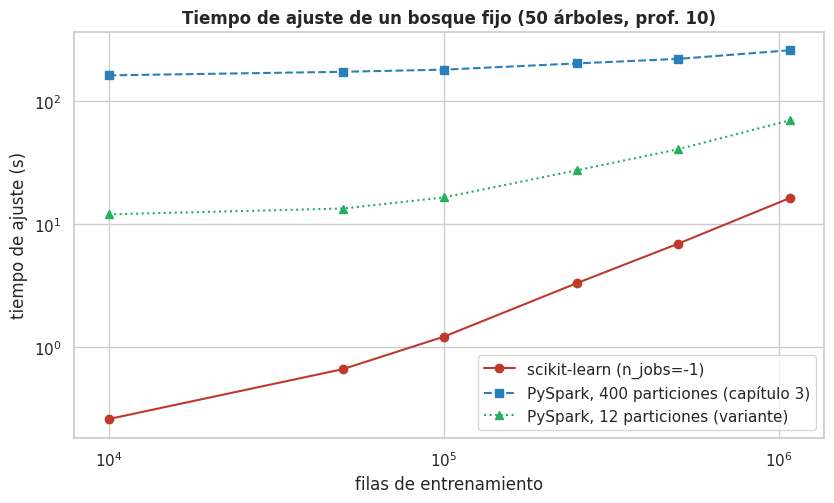

,costo fijo (s),costo por millón de filas (s),con el entrenamiento completo (s)
versión,,,
scikit-learn,-0.2269,15.0345,16.1910
PySpark (400 particiones),169.8932,86.2194,257.5911
PySpark (12 particiones),11.7380,54.4836,69.4192


En ningún volumen probado (hasta el entrenamiento completo) Spark fue más rápido que scikit-learn, con ninguna de las dos configuraciones.
PySpark (400 particiones): costo por fila 86 s por millón > scikit-learn 15: las rectas no se cruzan en el equipo utilizado.
PySpark (12 particiones): costo por fila 54 s por millón > scikit-learn 15: las rectas no se cruzan en el equipo utilizado.


In [6]:
es, ep = pd.read_csv(RESULTS / "escala_sklearn.csv"), pd.read_csv(RESULTS / "escala_spark.csv")
e12 = pd.read_csv(RESULTS / "escala_spark_12part.csv")
esc = (es.rename(columns={"t_ajuste_s": "sk", "auc_test": "auc_sk"})[["filas_train", "sk", "auc_sk"]]
       .merge(ep.rename(columns={"t_ajuste_s": "sp400", "auc_test": "auc_sp400"})[["filas_train", "sp400", "auc_sp400"]], on="filas_train")
       .merge(e12.rename(columns={"t_ajuste_s": "sp12"})[["filas_train", "sp12"]], on="filas_train"))
esc["Spark(400) / sklearn"], esc["Spark(12) / sklearn"] = esc["sp400"] / esc["sk"], esc["sp12"] / esc["sk"]
display(esc.style.format({"filas_train": "{:,.0f}", "sk": "{:.1f}", "sp400": "{:.1f}", "sp12": "{:.1f}", "auc_sk": "{:.4f}", "auc_sp400": "{:.4f}",
                          "Spark(400) / sklearn": "{:.1f}×", "Spark(12) / sklearn": "{:.1f}×"}))
fig, ax = plt.subplots(figsize=(8.5, 5.2))
ax.plot(esc["filas_train"], esc["sk"], "o-", color="#c0392b", label="scikit-learn (n_jobs=-1)")
ax.plot(esc["filas_train"], esc["sp400"], "s--", color="#2980b9", label="PySpark, 400 particiones (capítulo 3)")
ax.plot(esc["filas_train"], esc["sp12"], "^:", color="#27ae60", label="PySpark, 12 particiones (variante)")
ax.set(xscale="log", yscale="log", xlabel="filas de entrenamiento", ylabel="tiempo de ajuste (s)",
       title="Tiempo de ajuste de un bosque fijo (50 árboles, prof. 10)")
ax.legend()
plt.tight_layout()
plt.show()
rows = []
for nombre, col in (("scikit-learn", "sk"), ("PySpark (400 particiones)", "sp400"), ("PySpark (12 particiones)", "sp12")):
    b_, a_ = np.polyfit(esc["filas_train"].to_numpy(float), esc[col].to_numpy(), 1)
    rows.append({"versión": nombre, "costo fijo (s)": a_, "costo por millón de filas (s)": b_ * 1e6, "con el entrenamiento completo (s)": float(esc[col].iloc[-1])})
afin = pd.DataFrame(rows).set_index("versión")
display(afin)
b_sk = afin.loc["scikit-learn", "costo por millón de filas (s)"]
if ((esc["sp400"] < esc["sk"]) | (esc["sp12"] < esc["sk"])).any():
    print("Spark fue más rápido en algún volumen medido.")
else:
    print("En ningún volumen probado (hasta el entrenamiento completo) Spark fue más rápido que scikit-learn, con ninguna de las dos configuraciones.")
for v in ("PySpark (400 particiones)", "PySpark (12 particiones)"):
    b_sp = afin.loc[v, "costo por millón de filas (s)"]
    print(f"{v}: costo por fila {b_sp:.0f} s por millón " + (f"< scikit-learn {b_sk:.0f}: podrían cruzarse (extrapolación)." if b_sp < b_sk
                                                        else f"> scikit-learn {b_sk:.0f}: las rectas no se cruzan en el equipo utilizado."))

## 6.5 Efecto de cada elemento de la configuración de Spark

*Micro-benchmarks* del capítulo 3b (bosque pequeño fijo). "Factor" = cuántas veces tarda más (> 1) o menos
(< 1) la alternativa frente a la opción usada en los capítulos 3 y 3b.

In [7]:
abl = pd.read_csv(RESULTS / "spark_ablacion.csv")
display(abl.style.format({"con la condición (s)": "{:.1f}", "sin / alternativa (s)": "{:.1f}", "factor (alternativa / condición)": "{:.2f}"}))
cd = json.loads((RESULTS / "spark_costos.json").read_text())
print("createDataFrame desde pandas (segundos por llamada):")
display(pd.DataFrame(cd["createDataFrame_s"]).pivot(index="filas", columns="Arrow", values="createDataFrame + count (s)"))

,condición,con la condición (s),sin / alternativa (s),alternativa,factor (alternativa / condición)
0,"Caché tras VectorAssembler (5 árboles, prof. 5)",50.6,68.5,sin .persist(),1.35
1,"400 particiones del DataFrame de entrenamiento (10 árboles, prof. 10)",141.7,15.1,12 particiones,0.11
2,"CrossValidator con numFolds=3 (usado en los seis modelos) vs 2, malla de 2 combinaciones",395.0,281.6,numFolds=2,0.71
3,"CrossValidator parallelism=1 (elegido) vs 3, 3 pliegues, malla de 2 combinaciones",395.0,350.7,parallelism=3,0.89


createDataFrame desde pandas (segundos por llamada):


Arrow,no,sí
filas,,
1,512.8105,0.1673
100,501.7017,0.1107
5000,508.8281,0.2227


## 6.6 LIME: costo de explicar según el entorno

In [8]:
lime_sp = json.loads((RESULTS / "lime_spark.json").read_text())
lat = pd.DataFrame({"scikit-learn": sk["latencia_predict_s"], "PySpark (con Arrow)": lime_sp["latencia_predict_s"]})
lat.index.name = "filas por llamada"
lat["PySpark / scikit-learn"] = lat.iloc[:, 1] / lat.iloc[:, 0]
display(lat.style.format({"scikit-learn": "{:.4f} s", "PySpark (con Arrow)": "{:.3f} s", "PySpark / scikit-learn": "{:,.0f}×"}))
for k, v in lime_sp["instancias"].items():
    print(f"Una explicación LIME (5 000 muestras) de la instancia {k} con el modelo de Spark ({lm.NOMBRES[lime_sp['modelo']]}): {v['tiempo_s']:.1f} s")

,scikit-learn,PySpark (con Arrow),PySpark / scikit-learn
filas por llamada,,,
1,0.0002 s,0.287 s,"1,188×"
100,0.0006 s,0.275 s,489×
5000,0.0135 s,0.511 s,38×


Una explicación LIME (5 000 muestras) de la instancia FN con el modelo de Spark (Gradient boosting): 0.6 s
Una explicación LIME (5 000 muestras) de la instancia FP con el modelo de Spark (Gradient boosting): 0.6 s
